# Live Coding - TF-IDF, n-grams and sentiment analysis

In [2]:
import os
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

# Goal: Sentiment analysis of movie reviews

We want to predict whether short movie reviews in text form are positive or negative.

### Data: IMDB movie review dataset

We work with the *IMDB movie review dataset* for this purpose. It contains 40,000 reviews from the *IMDB* site that have been labeled as negative (<= 4/10) or positive (>= 7/10).

### Sources:
The data can be found on Moodle (`movie_reviews_train.csv`) and comes from Kaggle [link to dataset](https://www.kaggle.com/datasets/columbine/imdb-dataset-sentiment-analysis-in-csv-format?datasetId=429163&sortBy=voteCount).

Originally the data comes from here: https://ai.stanford.edu/~amaas/data/sentiment/

## Import and initial exploration
- Are any entries missing? How many entries are there?
- Which columns are there?
- View a sample text from the dataset
- What is the “corpus” and what is a “document”?
- Are the possible labels (positive/negative) well distributed?

In [3]:
filename = "../dataset/movie_reviews_train.csv"  # adjust path if necessary

data = pd.read_csv(filename)
data.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [4]:
data.label.value_counts()

label
0    20019
1    19981
Name: count, dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB


In [8]:
data.text[0]

'I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be Virgil or Scott. No one wanted to be Alan. Counting down from 5 became an art form. I took my children to see the movie hoping they would get a glimpse of what I loved as a child. How bitterly disappointing. The only high point was the snappy theme tune. Not that it could compare with the original score of the Thunderbirds. Thankfully early Saturday mornings one television channel still plays reruns of the series Gerry Anderson and his wife created. Jonatha Frakes should hand in his directors chair, his version was completely hopeless. A waste of film. Utter rubbish. A CGI remake may be acceptable but replacing marionettes with Homo sapiens subsp. sapiens was a huge error of judgment.'

In [9]:
data.text[1]

"When I put this movie in my DVD player, and sat down with a coke and some chips, I had some expectations. I was hoping that this movie would contain some of the strong-points of the first movie: Awsome animation, good flowing story, excellent voice cast, funny comedy and a kick-ass soundtrack. But, to my disappointment, not any of this is to be found in Atlantis: Milo's Return. Had I read some reviews first, I might not have been so let down. The following paragraph will be directed to those who have seen the first movie, and who enjoyed it primarily for the points mentioned.<br /><br />When the first scene appears, your in for a shock if you just picked Atlantis: Milo's Return from the display-case at your local videoshop (or whatever), and had the expectations I had. The music feels as a bad imitation of the first movie, and the voice cast has been replaced by a not so fitting one. (With the exception of a few characters, like the voice of Sweet). The actual drawings isnt that bad, 

In [ ]:
data["text_len"] = data.text.str.len()

<Axes: >

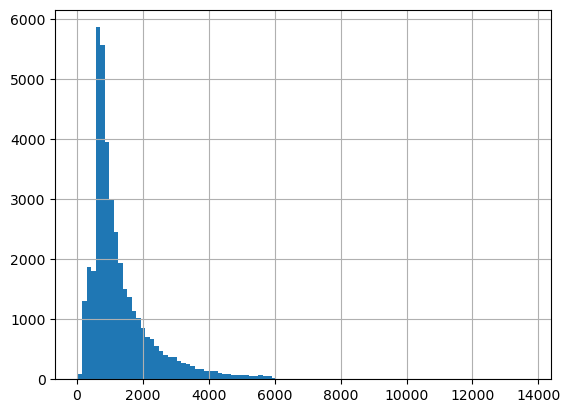

In [15]:
data.text_len.hist(bins=100)

## Find your own way...

`Scikit-Learn` has (as so often) some useful functions for us, including in the area of NLP. Here we will focus on calculating tf-idf values, for which there is the `TfidfVectorizer`.

See the documentation here: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html?highlight=tfidf#sklearn.feature_extraction.text.TfidfVectorizer

- What do `min_df` and `max_df` do?
- Try converting the “corpus” (data.text) into an array of feature vectors using the `TfidfVectorizer` (see documentation), e.g. with `min_df=2, max_df = 0.5`.
- How many features do we get?
- Look at the feature names with `.get_feature_names()`, with the latest Scikit-Learn version `.get_feature_names_out()`.

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidif = TfidfVectorizer(min_df=5, max_df=0.5)

tfidif_vectors = tfidif.fit_transform(data.text)

In [51]:
tfidif_vectors[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 90 stored elements and shape (1, 33620)>

In [52]:
tfidif_vectors[0].todense()

matrix([[0., 0., 0., ..., 0., 0., 0.]])

In [53]:
tfidif.get_feature_names_out()[-100:]

array(['zack', 'zadora', 'zahn', 'zandt', 'zane', 'zaniness', 'zanuck',
       'zany', 'zap', 'zappa', 'zapped', 'zara', 'zardoz', 'zarkov',
       'zasu', 'zatoichi', 'zeal', 'zealand', 'zealander', 'zealot',
       'zealots', 'zealous', 'zebra', 'zed', 'zeffirelli', 'zeitgeist',
       'zeke', 'zelah', 'zelda', 'zellweger', 'zellwegger', 'zeman',
       'zemeckis', 'zen', 'zena', 'zenith', 'zentropa', 'zephyr',
       'zeppelin', 'zero', 'zeroes', 'zest', 'zesty', 'zeta', 'zeus',
       'zhang', 'zhao', 'zhivago', 'zhou', 'zhu', 'zhuravli', 'ziering',
       'ziggy', 'zilch', 'zillion', 'zillions', 'zimbalist', 'zimmer',
       'zing', 'zingers', 'zip', 'zipper', 'zippo', 'zippy', 'zis',
       'ziyi', 'zizek', 'zodiac', 'zoe', 'zoey', 'zola', 'zombi',
       'zombie', 'zombies', 'zombification', 'zombified', 'zomcom',
       'zone', 'zoned', 'zones', 'zoo', 'zoolander', 'zoom', 'zoomed',
       'zooming', 'zooms', 'zoot', 'zorro', 'zosch', 'zu', 'zucco',
       'zucker', 'zula', 'zu

# Machine Learning --> Sentiment Analysis

To predict the labels (1/0 which stands for: positiv/negative), please train and evaluate a *logistic regression* model!

In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(tfidif_vectors, data.label)

LogisticRegression(max_iter=500)

## Test the model
To test the trained model, we take a data set (still unknown to the model): `movie_reviews_test.csv`.

- Specify the labels for the test data in advance
- Measure the accuracy with `from sklearn.metrics import accuracy_score`
- Create a confusion matrix (`from sklearn.metrics import confusion_matrix`)

In [57]:
filename = "../dataset/movie_reviews_test.csv"  # adjust path if necessary

data_test = pd.read_csv(filename)
data_test.head()

,text,label
0,I always wrote this series off as being a comp...,0
1,1st watched 12/7/2002 - 3 out of 10(Dir-Steve ...,0
2,This movie was so poorly written and directed ...,0
3,The most interesting thing about Miryang (Secr...,1
4,"when i first read about ""berlin am meer"" i did...",0


In [58]:
test_vectors = tfidif.transform(data_test.text)
predictions = model.predict(test_vectors)

In [61]:
predictions[:100]

array([0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0])

In [67]:
(data_test.label.values == predictions).sum() / data_test.label.count()

np.float64(0.8978)

## Interpreting the model

One of the advantages of *logistic regression* is that we can see what the model has actually “learned.” To do this, we can output the learned coefficients with `model.coef_`

- Which words are most important for a negative or positive rating (display the top 10 for each)

In [68]:
model.coef_.shape

(1, 33620)

In [69]:
model.coef_

array([[-0.20151806, -0.47704189, -0.04685974, ..., -0.01849228,
         0.07390661, -0.04928113]])

In [70]:
np.argmax(model.coef_)

np.int64(13029)

In [71]:
tfidif.get_feature_names_out()[13029]

'great'

In [ ]:
np.argmax(model.coef_)

In [92]:
pos_idx = np.argsort(model.coef_)[0, -5:]

In [93]:
tfidif.get_feature_names_out()[pos_idx]

array(['amazing', 'wonderful', 'best', 'excellent', 'great'], dtype=object)

In [99]:
neg_idx = np.argsort(model.coef_)[0, :5]

In [101]:
tfidif.get_feature_names_out()[neg_idx]

array(['worst', 'bad', 'waste', 'awful', 'boring'], dtype=object)

# Comparison: 2-grams, 3-grams...

So far, we have only worked with 1-grams (i.e., individual words). However, we can also count and add the frequencies of 2-grams, etc. To do this, simply set the `ngram_range` parameter in the `TfidfVectorizer` to, for example, `(1, 2)` (1-grams and 2-grams).

Since this results in significantly more terms, min_df and max_df should also be adjusted, e.g., set `min_df` to a higher value (e.g., 6 or 10... just try it out).

Another alternative way to limit the number of features in the Tfidf vectors is to use the `max_features` parameter.

- Does this give a better prediction of the labels?